In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted at /content/drive")

Mounted at /content/drive
Google Drive mounted at /content/drive


In [2]:
!pip install -q sentence-transformers gensim tensorflow-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.8 MB/s eta 0:00:00


In [3]:
import os

In [4]:
project_path = '/content/drive/MyDrive/sentiment_analysis_project'
os.makedirs(project_path, exist_ok=True)
os.makedirs(f'{project_path}/features', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)

print(f"Project folder: {project_path}")

Project folder: /content/drive/MyDrive/sentiment_analysis_project


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv('/content/yelp_train_100k.csv', engine='python')

In [10]:
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

Dataset loaded: (93938, 2)
Columns: ['text', 'label']

Class distribution:
label
1.0    46994
0.0    46943
Name: count, dtype: int64


In [12]:
# Train/validation split (80/20, stratified)

# Drop rows with NaN values in the 'label' column to ensure stratification works correctly
df_cleaned = df.dropna(subset=['label'])

X = df_cleaned['text']
y = df_cleaned['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set: {len(X_train):,} samples")
print(f"Val set: {len(X_val):,} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nVal class distribution:\n{y_val.value_counts()}")


Train set: 75,149 samples
Val set: 18,788 samples

Train class distribution:
label
1.0    37595
0.0    37554
Name: count, dtype: int64

Val class distribution:
label
1.0    9399
0.0    9389
Name: count, dtype: int64


## Inspecting TF-IDF Features

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

In [20]:
def clean_text(text):
    text = re.sub(r'\n', ' ', text)  # Remove newlines
    text = re.sub(r"n't", " not", text)  # don't → do not
    text = re.sub(r"'ve", " have", text)  # I've → I have
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ll", " will", text)
    return text

# Apply to data before TF-IDF
X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)

In [21]:
# Initialize vectorizer with stopword removal
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),      # Unigrams, bigrams, trigrams
    max_features=5000,       # Limit to top 5000 features
    min_df=5,                # Ignore rare terms (appear in <5 docs)
    max_df=0.8,              # Ignore very common terms (appear in >80% of docs)
    stop_words='english',    # ← ADD THIS: Remove English stopwords
    sublinear_tf=True,       # Apply log scaling to term frequency
    strip_accents='unicode', # Remove accents
    lowercase=True
)

# Fit on training data only
print("Fitting TF-IDF vectorizer on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation data
print("Transforming validation data...")
X_val_tfidf = tfidf.transform(X_val)

print(f"\nTF-IDF features created")
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Val shape: {X_val_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

Fitting TF-IDF vectorizer on training data...
Transforming validation data...

TF-IDF features created
Train shape: (75149, 5000)
Val shape: (18788, 5000)
Vocabulary size: 5000


In [22]:
# STEP 4: Inspect top TF-IDF features
import numpy as np

# Get feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Calculate mean TF-IDF score per feature across all documents
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()

# Get top 20 features by mean TF-IDF score
top_indices = mean_tfidf.argsort()[-20:][::-1]
top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

print("\n" + "="*80)
print("TOP 20 TF-IDF FEATURES (by mean score)")
print("="*80)
for feat, score in zip(top_features, top_scores):
    print(f"{feat:40s}: {score:.6f}")


TOP 20 TF-IDF FEATURES (by mean score)
food                                    : 0.029086
place                                   : 0.027938
good                                    : 0.026572
great                                   : 0.024713
service                                 : 0.022861
like                                    : 0.021312
just                                    : 0.021013
time                                    : 0.019947
really                                  : 0.017128
don                                     : 0.014706
ve                                      : 0.014278
got                                     : 0.014035
best                                    : 0.013795
nice                                    : 0.013727
love                                    : 0.013208
ni                                      : 0.013053
went                                    : 0.012431
staff                                   : 0.012283
people                                  : 

In [24]:
# Save TF-IDF features and vectorizer to Drive
import joblib

# Save vectorizer (for later use in deployment)
joblib.dump(tfidf, f'{project_path}/models/tfidf_vectorizer.pkl')

# Save feature matrices
joblib.dump(X_train_tfidf, f'{project_path}/features/X_train_tfidf.pkl')
joblib.dump(X_val_tfidf, f'{project_path}/features/X_val_tfidf.pkl')

# Save labels too
joblib.dump(y_train, f'{project_path}/features/y_train.pkl')
joblib.dump(y_val, f'{project_path}/features/y_val.pkl')

print("\nTF-IDF features saved to Drive")
print(f"   - Vectorizer: models/tfidf_vectorizer.pkl")
print(f"   - Train features: features/X_train_tfidf.pkl")
print(f"   - Val features: features/X_val_tfidf.pkl")


TF-IDF features saved to Drive
   - Vectorizer: models/tfidf_vectorizer.pkl
   - Train features: features/X_train_tfidf.pkl
   - Val features: features/X_val_tfidf.pkl


## Word2Vec Modelling

In [25]:
import gensim.downloader as api
from tqdm import tqdm
import numpy as np

In [26]:
w2v_model = api.load('word2vec-google-news-300')

print(f"\nWord2Vec model loaded")
print(f"Vocabulary size: {len(w2v_model):,} words")
print(f"Vector dimensions: {w2v_model.vector_size}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded

Word2Vec model loaded
Vocabulary size: 3,000,000 words
Vector dimensions: 300


In [27]:
# Function to convert text to Word2Vec embedding (average of word vectors)
def text_to_word2vec(text, model):
    """
    Convert text to Word2Vec embedding by averaging word vectors.
    Returns 300-dim vector.
    """
    words = text.lower().split()

    # Get vectors for words that exist in vocabulary
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])

    # Average the vectors (or return zeros if no words found)
    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Test on a sample review
sample_text = X_train.iloc[0]
sample_embedding = text_to_word2vec(sample_text, w2v_model)
print(f"\nSample embedding shape: {sample_embedding.shape}")
print(f"First 10 dimensions: {sample_embedding[:10]}")


Sample embedding shape: (300,)
First 10 dimensions: [ 0.0012728   0.03375304  0.02530543  0.09209689 -0.0755895  -0.00039419
  0.02096748 -0.07724508  0.06296793  0.08235931]


In [28]:
# STEP 6: Generate Word2Vec embeddings for all reviews
print("\nGenerating Word2Vec embeddings for training set...")
X_train_w2v = np.array([
    text_to_word2vec(text, w2v_model)
    for text in tqdm(X_train, desc="Train")
])

print("\nGenerating Word2Vec embeddings for validation set...")
X_val_w2v = np.array([
    text_to_word2vec(text, w2v_model)
    for text in tqdm(X_val, desc="Val")
])

print(f"\nWord2Vec embeddings created")
print(f"Train shape: {X_train_w2v.shape}")
print(f"Val shape: {X_val_w2v.shape}")


Generating Word2Vec embeddings for training set...


Train: 100%|██████████| 75149/75149 [00:20<00:00, 3615.15it/s]



Generating Word2Vec embeddings for validation set...


Val: 100%|██████████| 18788/18788 [00:04<00:00, 3790.01it/s]


✓ Word2Vec embeddings created
Train shape: (75149, 300)
Val shape: (18788, 300)


In [30]:
# Save Word2Vec embeddings to Drive
joblib.dump(X_train_w2v, f'{project_path}/features/X_train_w2v.pkl')
joblib.dump(X_val_w2v, f'{project_path}/features/X_val_w2v.pkl')

print("\nWord2Vec embeddings saved to Drive")
print(f"   - Train: features/X_train_w2v.pkl")
print(f"   - Val: features/X_val_w2v.pkl")


Word2Vec embeddings saved to Drive
   - Train: features/X_train_w2v.pkl
   - Val: features/X_val_w2v.pkl


## Universal Sentence Encoder (USE)

In [31]:
import tensorflow_hub as hub
import tensorflow as tf

In [32]:
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

In [33]:
# Generate USE embeddings in batches (to avoid OOM)
def get_use_embeddings(texts, model, batch_size=64):
    """
    Generate USE embeddings for a list of texts.
    Process in batches to manage memory.
    """
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="USE batches"):
        batch = texts[i:i+batch_size].tolist()
        batch_embeddings = model(batch).numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# Generate embeddings for train set
print("\nGenerating USE embeddings for training set...")
X_train_use = get_use_embeddings(X_train, use_model, batch_size=64)

# Generate embeddings for validation set
print("\nGenerating USE embeddings for validation set...")
X_val_use = get_use_embeddings(X_val, use_model, batch_size=64)

print(f"\nUSE embeddings created")
print(f"Train shape: {X_train_use.shape}")
print(f"Val shape: {X_val_use.shape}")


Generating USE embeddings for training set...


USE batches: 100%|██████████| 1175/1175 [01:02<00:00, 18.90it/s]



Generating USE embeddings for validation set...


USE batches: 100%|██████████| 294/294 [00:14<00:00, 20.55it/s]



USE embeddings created
Train shape: (75149, 512)
Val shape: (18788, 512)


In [34]:
# STEP 8: Save USE embeddings
joblib.dump(X_train_use, f'{project_path}/features/X_train_use.pkl')
joblib.dump(X_val_use, f'{project_path}/features/X_val_use.pkl')

print("\nUSE embeddings saved to Drive")
print(f"   - Train: features/X_train_use.pkl")
print(f"   - Val: features/X_val_use.pkl")


✓ USE embeddings saved to Drive
   - Train: features/X_train_use.pkl
   - Val: features/X_val_use.pkl


In [35]:
# Feature dimensionality comparison
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPARISON — DIMENSIONALITY")
print("="*80)

comparison_data = {
    'Feature Method': ['TF-IDF (1-3 grams)', 'Word2Vec (averaged)', 'Universal Sentence Encoder'],
    'Type': ['Sparse', 'Dense', 'Dense'],
    'Dimensions': [5000, 300, 512],
    'Train Shape': [
        f"{X_train_tfidf.shape}",
        f"{X_train_w2v.shape}",
        f"{X_train_use.shape}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*80)


FEATURE ENGINEERING COMPARISON — DIMENSIONALITY
            Feature Method   Type  Dimensions   Train Shape
        TF-IDF (1-3 grams) Sparse        5000 (75149, 5000)
       Word2Vec (averaged)  Dense         300  (75149, 300)
Universal Sentence Encoder  Dense         512  (75149, 512)


## BERT Embeddings (sentence-transformers)

In [36]:
from sentence_transformers import SentenceTransformer

In [37]:
bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [38]:
device = 'cuda' if tf.config.list_physical_devices('GPU') else 'cpu'
bert_model = bert_model.to(device)

print(f"\nBERT model loaded on {device}")
print(f"Embedding dimension: {bert_model.get_sentence_embedding_dimension()}")


BERT model loaded on cuda
Embedding dimension: 384


In [39]:
# Generate BERT embeddings
print("\nGenerating BERT embeddings for training set...")
X_train_bert = bert_model.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating BERT embeddings for validation set...")
X_val_bert = bert_model.encode(
    X_val.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\n✓ BERT embeddings created")
print(f"Train shape: {X_train_bert.shape}")
print(f"Val shape: {X_val_bert.shape}")


Generating BERT embeddings for training set...


Batches:   0%|          | 0/2349 [00:00<?, ?it/s]


Generating BERT embeddings for validation set...


Batches:   0%|          | 0/588 [00:00<?, ?it/s]


✓ BERT embeddings created
Train shape: (75149, 384)
Val shape: (18788, 384)


In [40]:
# STEP 10: Save BERT embeddings
joblib.dump(X_train_bert, f'{project_path}/features/X_train_bert.pkl')
joblib.dump(X_val_bert, f'{project_path}/features/X_val_bert.pkl')

print("\nBERT embeddings saved to Drive")
print(f"   - Train: features/X_train_bert.pkl")
print(f"   - Val: features/X_val_bert.pkl")


BERT embeddings saved to Drive
   - Train: features/X_train_bert.pkl
   - Val: features/X_val_bert.pkl


In [42]:
# Final feature comparison table
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPARISON — ALL METHODS")
print("="*80)

final_comparison = {
    'Feature Method': [
        'TF-IDF (1-3 grams)',
        'Word2Vec (averaged)',
        'Universal Sentence Encoder',
        'BERT (all-MiniLM-L6-v2)'
    ],
    'Type': ['Sparse', 'Dense', 'Dense', 'Dense'],
    'Dimensions': [5000, 300, 512, 384],
    'Train Shape': [
        str(X_train_tfidf.shape),
        str(X_train_w2v.shape),
        str(X_train_use.shape),
        str(X_train_bert.shape)
    ],
    'Approach': [
        'N-gram frequencies',
        'Word-level semantics',
        'Sentence-level semantics',
        'Transformer attention'
    ]
}

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))
print("="*80)
print("\nAll 4 feature representations complete!")


FEATURE ENGINEERING COMPARISON — ALL METHODS
            Feature Method   Type  Dimensions   Train Shape                 Approach
        TF-IDF (1-3 grams) Sparse        5000 (75149, 5000)       N-gram frequencies
       Word2Vec (averaged)  Dense         300  (75149, 300)     Word-level semantics
Universal Sentence Encoder  Dense         512  (75149, 512) Sentence-level semantics
   BERT (all-MiniLM-L6-v2)  Dense         384  (75149, 384)    Transformer attention

All 4 feature representations complete!


## Feature Visualization (t-SNE)

In [43]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [44]:
# Sample 5000 reviews for t-SNE (it's slow on full dataset)
np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

y_train_array = y_train.values  # Convert to numpy for indexing

# Prepare subsets for each feature method
tfidf_sample = X_train_tfidf[sample_indices].toarray()  # Convert sparse to dense
w2v_sample = X_train_w2v[sample_indices]
use_sample = X_train_use[sample_indices]
bert_sample = X_train_bert[sample_indices]
labels_sample = y_train_array[sample_indices]

print(f"Sampled {sample_size} reviews for t-SNE visualization")

Sampled 5000 reviews for t-SNE visualization


In [45]:
# Apply t-SNE to each feature method
print("\nApplying t-SNE dimensionality reduction.")

tsne_results = {}

# TF-IDF
print("  - TF-IDF...")
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results['TF-IDF'] = tsne_tfidf.fit_transform(tfidf_sample)

# Word2Vec
print("  - Word2Vec...")
tsne_w2v = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results['Word2Vec'] = tsne_w2v.fit_transform(w2v_sample)

# USE
print("  - Universal Sentence Encoder...")
tsne_use = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results['USE'] = tsne_use.fit_transform(use_sample)

# BERT
print("  - BERT...")
tsne_bert = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results['BERT'] = tsne_bert.fit_transform(bert_sample)

print("\nt-SNE completed for all methods")


Applying t-SNE dimensionality reduction.
  - TF-IDF...
  - Word2Vec...
  - Universal Sentence Encoder...
  - BERT...

t-SNE completed for all methods


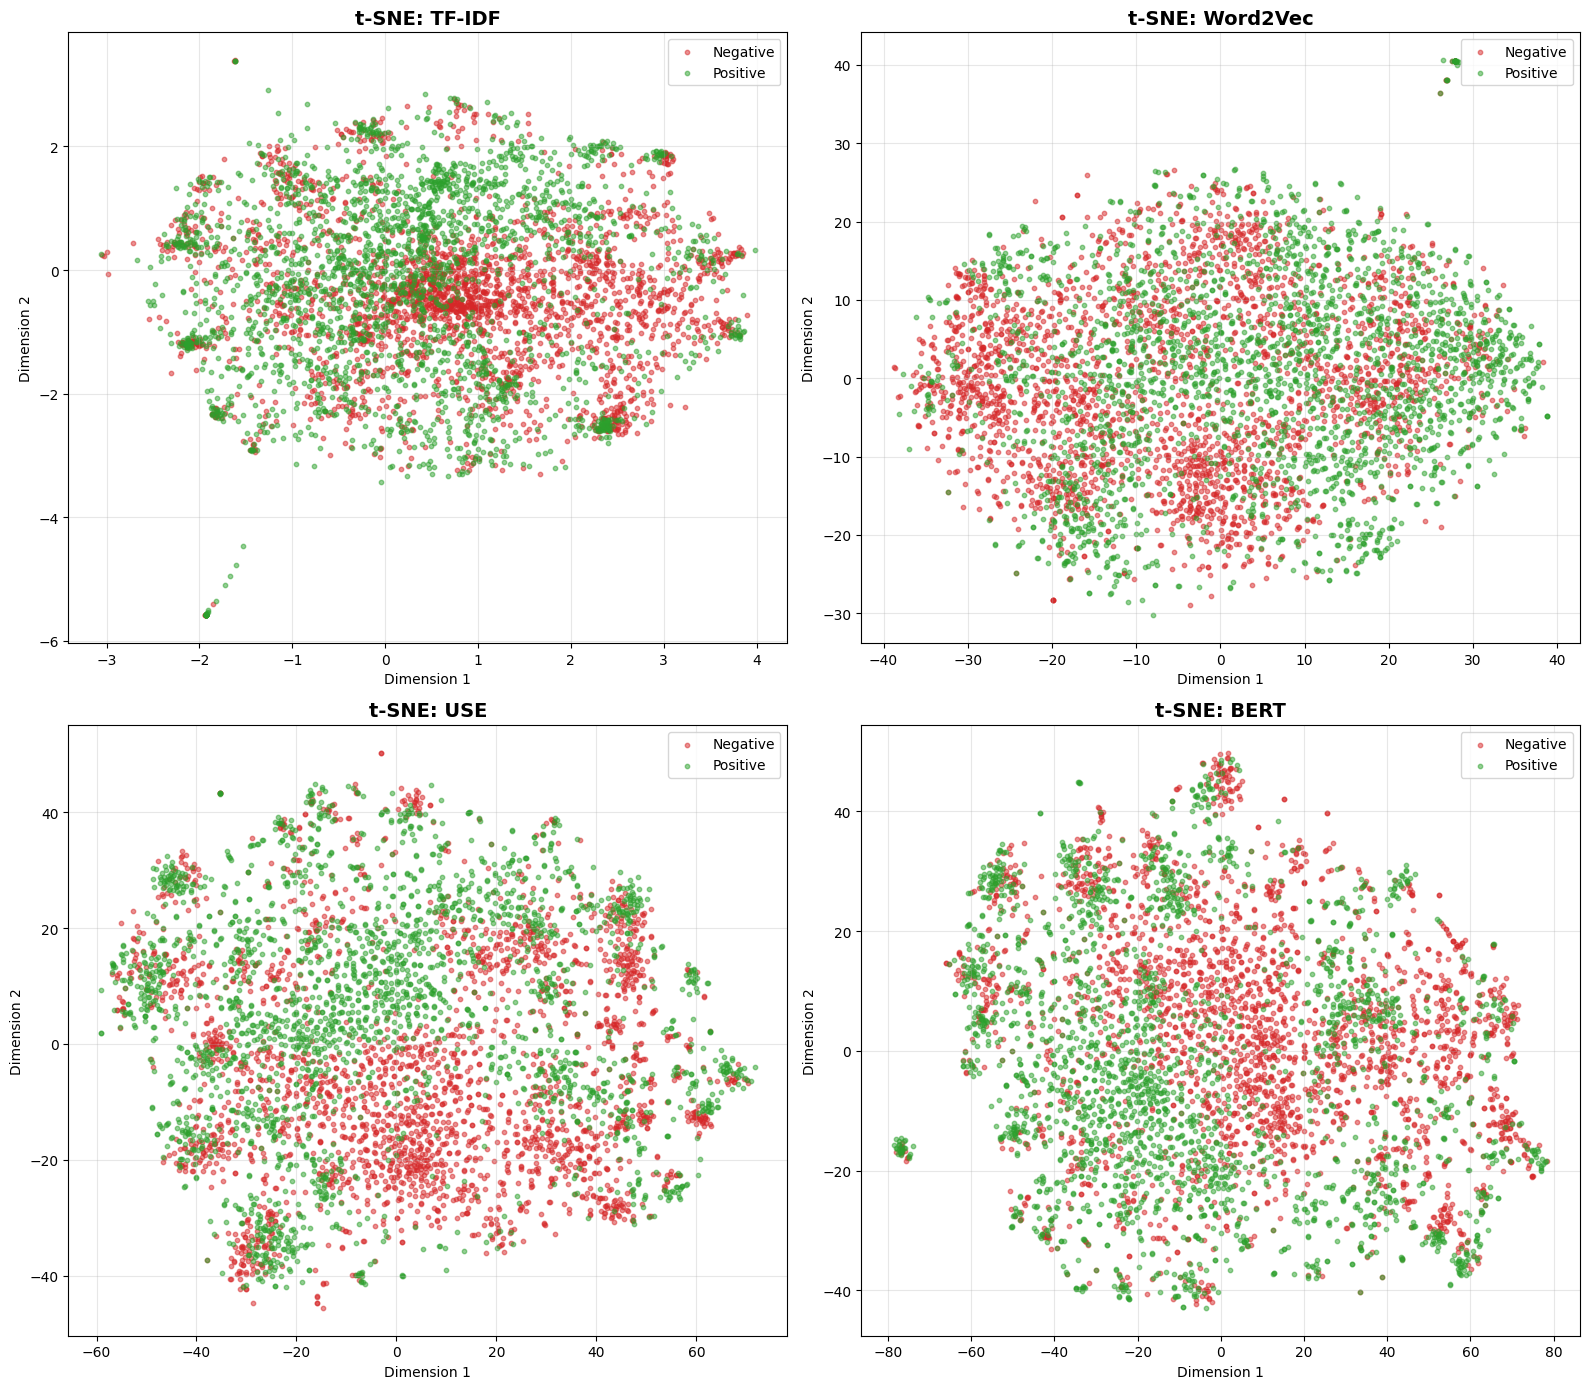


t-SNE visualization saved: feature_comparison_tsne.png


In [46]:
# STEP 12: Visualize t-SNE results
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

methods = ['TF-IDF', 'Word2Vec', 'USE', 'BERT']
colors = {0: '#d62728', 1: '#2ca02c'}  # Red for negative, green for positive

for idx, method in enumerate(methods):
    ax = axes[idx]

    # Plot negative reviews
    mask_neg = labels_sample == 0
    ax.scatter(
        tsne_results[method][mask_neg, 0],
        tsne_results[method][mask_neg, 1],
        c=colors[0], label='Negative', alpha=0.5, s=10
    )

    # Plot positive reviews
    mask_pos = labels_sample == 1
    ax.scatter(
        tsne_results[method][mask_pos, 0],
        tsne_results[method][mask_pos, 1],
        c=colors[1], label='Positive', alpha=0.5, s=10
    )

    ax.set_title(f't-SNE: {method}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/feature_comparison_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nt-SNE visualization saved: feature_comparison_tsne.png")

In [47]:
# Notebook 02 Summary
print("\n" + "="*80)
print("NOTEBOOK 02 SUMMARY — FEATURE ENGINEERING COMPLETE")
print("="*80)

summary = {
    'Feature Method': ['TF-IDF', 'Word2Vec', 'USE', 'BERT'],
    'Dimensions': [5000, 300, 512, 384],
    'Train Samples': [75149, 75149, 75149, 75149],
    'Val Samples': [18788, 18788, 18788, 18788],
    'Files Saved': [
        'X_train_tfidf.pkl, X_val_tfidf.pkl',
        'X_train_w2v.pkl, X_val_w2v.pkl',
        'X_train_use.pkl, X_val_use.pkl',
        'X_train_bert.pkl, X_val_bert.pkl'
    ],
    'Expected Performance': ['Baseline', 'Good', 'Better', 'Best']
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("- All feature matrices saved to Google Drive")
print("- Ready for Notebook 03: Model Competition")
print("- Ensemble features (PCA + stacking) will be created during modeling")
print("="*80)


NOTEBOOK 02 SUMMARY — FEATURE ENGINEERING COMPLETE
Feature Method  Dimensions  Train Samples  Val Samples                        Files Saved Expected Performance
        TF-IDF        5000          75149        18788 X_train_tfidf.pkl, X_val_tfidf.pkl             Baseline
      Word2Vec         300          75149        18788     X_train_w2v.pkl, X_val_w2v.pkl                 Good
           USE         512          75149        18788     X_train_use.pkl, X_val_use.pkl               Better
          BERT         384          75149        18788   X_train_bert.pkl, X_val_bert.pkl                 Best

NEXT STEPS
- All feature matrices saved to Google Drive
- Ready for Notebook 03: Model Competition
- Ensemble features (PCA + stacking) will be created during modeling
